Target Run ID: 20251130_153500
Output Directory: /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/20251026_under_25clusters_program_and_result/for_checking_20251127/Thesis_Figures/run_20251130_153500/Clustering_Validation

--- Generating Main Text Figures (Clustering Indices) ---
  -> Generated Indices Grid for OH
  -> Generated Indices Grid for FP
  -> Generated Indices Grid for A_OH_plus_others
  -> Generated Indices Grid for B_FP_plus_others
  -> Generated Indices Grid for C_OH_only


/tmp/ipykernel_78524/2116684003.py:106: FutureWarning: The behavior of Series.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  best_idx = df["score"].idxmax() if direction == "max" else df["score"].idxmin()


KeyError: nan

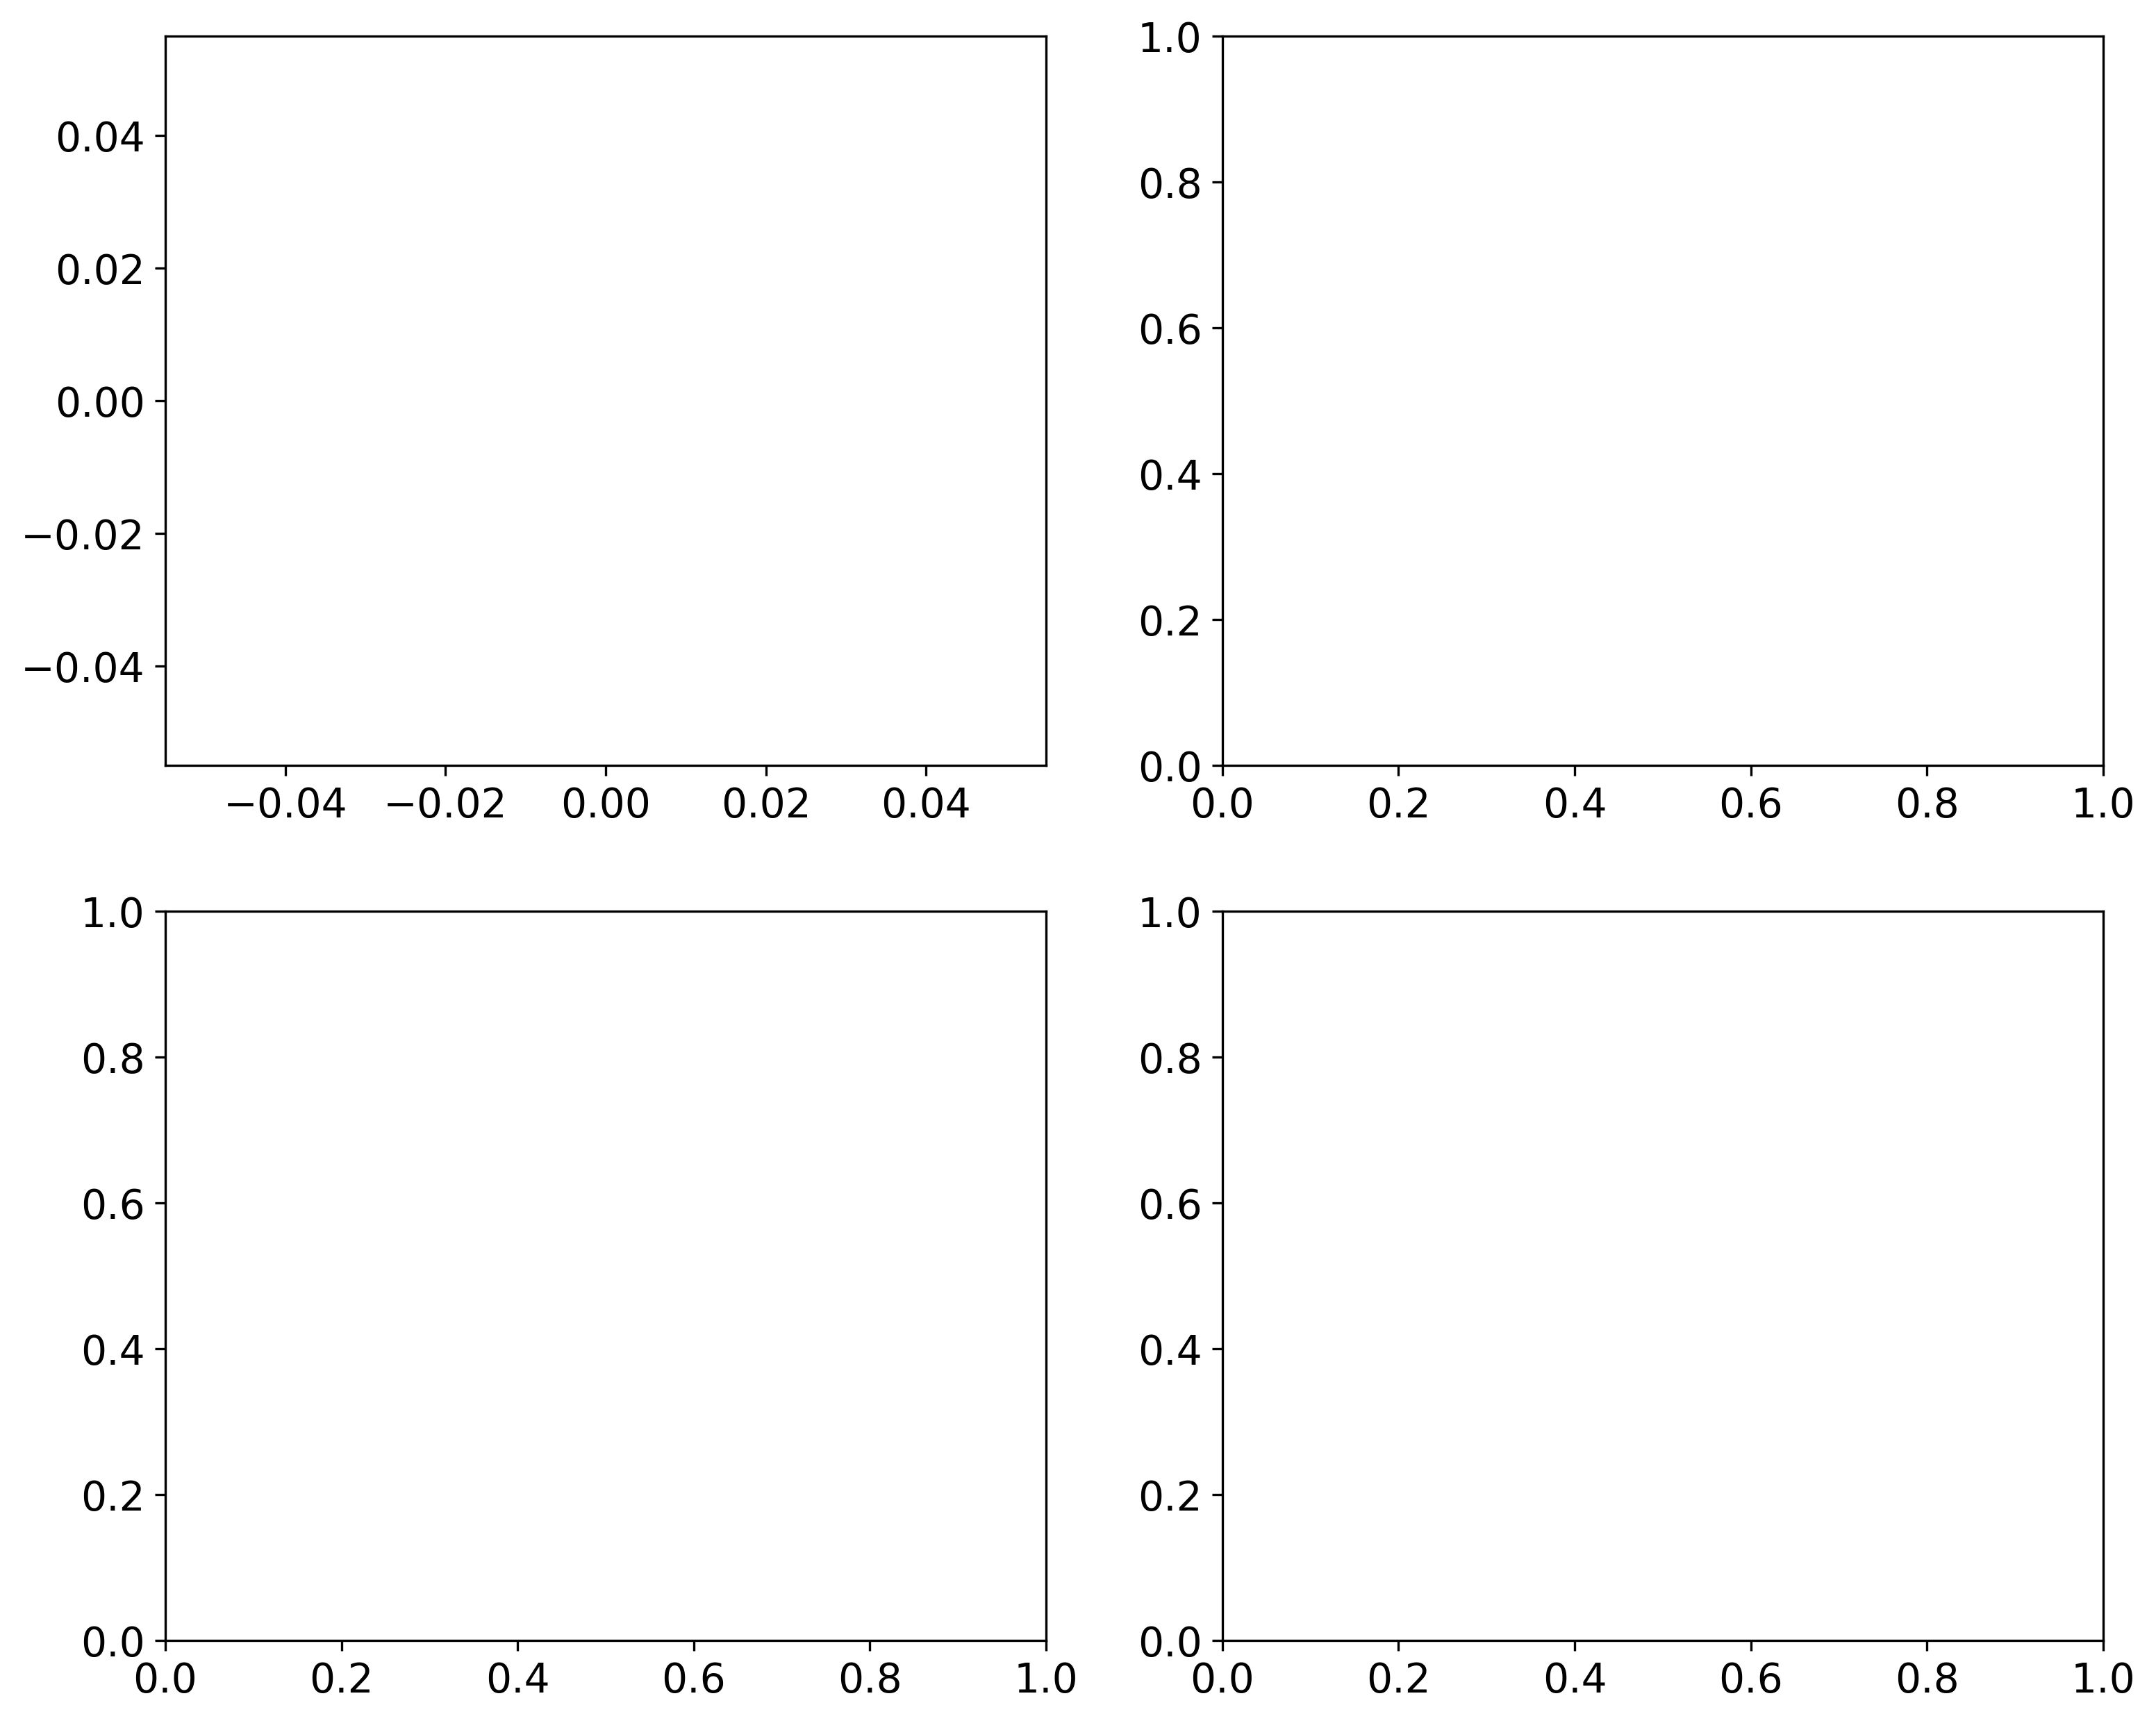

In [3]:
# STEP3.2_06_thesis_clustering_plots_v2.py
#
# 変更点: 出力先を 'Clustering_Validation' フォルダに変更して整理
#

import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
from sklearn.metrics import adjusted_rand_score

# ==========================================
# 1. 設定 (Configuration)
# ==========================================

# ★ここをあなたの環境に合わせて書き換えてください★
RUN_ID = "20251130_153500"  # Rで計算したID
ROOT_BASE = "/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/20251026_under_25clusters_program_and_result/for_checking_20251127"

# 入力元 (Rの出力フォルダ)
CLUSTERING_SUB_DIR = os.path.join(ROOT_BASE, "sub", "03_clustering_STEP3.2_signlessCorr", f"run_{RUN_ID}")

# ★変更点: 出力先フォルダを一段階深く作成 ('Clustering_Validation')
OUTPUT_FIG_DIR = os.path.join(ROOT_BASE, "Thesis_Figures", f"run_{RUN_ID}", "Clustering_Validation")

# フォルダ作成
os.makedirs(OUTPUT_FIG_DIR, exist_ok=True)

# プロットスタイル
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Helvetica']
plt.rcParams['font.size'] = 14
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

# データセット定義
ALL_DATASETS = ["OH", "FP", "A_OH_plus_others", "B_FP_plus_others", "C_OH_only", "D_FP_only"]

# 主要な指標
MAIN_INDICES = ["silhouette", "gap", "dunn", "ch"]
INDEX_LABELS = {
    "silhouette": "(a) Silhouette (max)",
    "gap":        "(b) Gap Statistic (max)",
    "dunn":       "(c) Dunn Index (max)",
    "ch":         "(d) Calinski-Harabasz (max)"
}
INDEX_DIRECTIONS = {
    "silhouette": "max", "gap": "max", "dunn": "max", "ch": "max",
    "db": "min", "ptbiserial": "max"
}

print(f"Target Run ID: {RUN_ID}")
print(f"Output Directory: {OUTPUT_FIG_DIR}")

# ==========================================
# 2. ヘルパー関数
# ==========================================

def load_k_scores(dataset, unit, mode_dim="linear_top3", index="silhouette"):
    """R出力の k_score_*.csv を読み込む"""
    fname = f"k_score_{mode_dim}_{unit}_{dataset}_{index}_{RUN_ID}.csv"
    path = os.path.join(CLUSTERING_SUB_DIR, unit, dataset, "indices", fname)
    if not os.path.exists(path):
        return None
    return pd.read_csv(path)

def load_cluster_labels(dataset, unit, mode_dim="linear_top3", k_num=10):
    """R出力の固定kラベル (ClusterAssign_...kXX...) を読み込む"""
    fname = f"ClusterAssign_{mode_dim}_k{k_num}_{unit}_{dataset}_{RUN_ID}.csv"
    path = os.path.join(CLUSTERING_SUB_DIR, unit, dataset, "labels", fname)
    if not os.path.exists(path):
        return None
    df = pd.read_csv(path)
    if "Cluster" in df.columns:
        return df["Cluster"].values
    return None

# ==========================================
# 3. 図表作成: Main Text用 (指標グリッド図)
# ==========================================
print("\n--- Generating Main Text Figures (Clustering Indices) ---")

def plot_indices_grid(dataset):
    unit = "variables" if dataset in ["OH", "FP"] else "samples"
    target_mode = "linear_top3"

    fig = plt.figure(figsize=(12, 10))
    gs = GridSpec(2, 2, figure=fig)
    axes = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1]),
            fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])]
    
    colors = sns.color_palette("deep", len(MAIN_INDICES))
    plot_count = 0
    
    for i, (ax, index) in enumerate(zip(axes, MAIN_INDICES)):
        df = load_k_scores(dataset, unit, mode_dim=target_mode, index=index)
        if df is None or len(df) == 0: continue
        
        plot_count += 1
        ax.plot(df["k"], df["score"], marker='o', linestyle='-', linewidth=2, color=colors[i], alpha=0.8, label=target_mode)
        
        direction = INDEX_DIRECTIONS.get(index, "max")
        best_idx = df["score"].idxmax() if direction == "max" else df["score"].idxmin()
        best_k = df.loc[best_idx, "k"]
        best_score = df.loc[best_idx, "score"]
        
        # 赤丸強調
        ax.plot(best_k, best_score, marker='o', markersize=12, 
                markerfacecolor='none', markeredgecolor='red', markeredgewidth=2)
        ax.annotate(f"k={int(best_k)}", (best_k, best_score), 
                    xytext=(5, 5), textcoords='offset points', color='red', fontweight='bold')
        
        ax.set_title(INDEX_LABELS[index], fontweight="bold", loc='left')
        ax.set_xlabel("Number of clusters ($k$)")
        ax.set_ylabel("Score value")
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.set_xticks(np.arange(min(df["k"]), max(df["k"])+1, 2))
    
    if plot_count > 0:
        plt.suptitle(f"Clustering Validation Indices: {dataset} (Linear Top3)", y=0.98, fontsize=18, fontweight="bold")
        plt.tight_layout(rect=[0, 0.03, 1, 0.98])
        
        save_name = f"Main_Clustering_Indices_BestK_Grid_{dataset}"
        plt.savefig(os.path.join(OUTPUT_FIG_DIR, f"{save_name}.png"))
        plt.savefig(os.path.join(OUTPUT_FIG_DIR, f"{save_name}.pdf"))
        plt.close()
        print(f"  -> Generated Indices Grid for {dataset}")
    else:
        print(f"  -> [SKIP] No data found for {dataset}")

for ds in ALL_DATASETS:
    plot_indices_grid(ds)


# ==========================================
# 4. 図表作成: Appendix用 (解像度間ARIヒートマップ)
# ==========================================
print("\n--- Generating Appendix Figures (Resolution ARI Heatmap) ---")

def plot_resolution_heatmap(dataset):
    unit = "variables" if dataset in ["OH", "FP"] else "samples"
    target_mode = "linear_top3"
    
    k_levels = [10, 25, 50]
    n_levels = len(k_levels)
    ari_matrix = np.zeros((n_levels, n_levels))
    
    labels_map = {}
    for k in k_levels:
        labels_map[k] = load_cluster_labels(dataset, unit, target_mode, k)
        
    if any(l is None for l in labels_map.values()):
        print(f"  -> [SKIP] Missing fixed-k labels for {dataset}")
        return

    for i in range(n_levels):
        for j in range(n_levels):
            if i == j:
                ari_matrix[i, j] = 1.0
            else:
                lab_i = labels_map[k_levels[i]]
                lab_j = labels_map[k_levels[j]]
                if len(lab_i) == len(lab_j):
                    ari_matrix[i, j] = adjusted_rand_score(lab_i, lab_j)
                else:
                    ari_matrix[i, j] = np.nan

    fig, ax = plt.subplots(figsize=(7, 6))
    mask = np.triu(np.ones_like(ari_matrix, dtype=bool))
    
    sns.heatmap(ari_matrix, mask=mask, annot=True, fmt=".2f", cmap="YlGnBu", 
                vmin=0, vmax=1, cbar_kws={'label': 'Adjusted Rand Index (ARI)'},
                xticklabels=[f"k={k}" for k in k_levels],
                yticklabels=[f"k={k}" for k in k_levels],
                ax=ax, annot_kws={"size": 14, "weight": "bold"})
    
    ax.set_title(f"Resolution Consistency (ARI): {dataset}\n(Linear Top3)", fontweight="bold")
    plt.yticks(rotation=0) 
    plt.tight_layout()
    
    save_name = f"Appendix_ARI_Resolution_Heatmap_{dataset}"
    plt.savefig(os.path.join(OUTPUT_FIG_DIR, f"{save_name}.png"))
    plt.savefig(os.path.join(OUTPUT_FIG_DIR, f"{save_name}.pdf"))
    plt.close()
    print(f"  -> Generated ARI Heatmap for {dataset}")

for ds in ALL_DATASETS:
    plot_resolution_heatmap(ds)

print("\n✅ All Clustering Figures Generated Successfully!")
print(f"Check the folder: {OUTPUT_FIG_DIR}")

Target Run ID: 20251130_153500
Output Directory: /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/20251026_under_25clusters_program_and_result/for_checking_20251127/Thesis_Figures/run_20251130_153500/Clustering_Validation

--- Generating Main Text Figures (Clustering Indices) ---
  -> Generated Indices Grid for OH
  -> Generated Indices Grid for FP
  -> Generated Indices Grid for A_OH_plus_others
  -> Generated Indices Grid for B_FP_plus_others
  -> Generated Indices Grid for C_OH_only
  -> [SKIP] No valid index data found for D_FP_only

--- Generating Appendix Figures (Resolution ARI Heatmap) ---
  -> Generated ARI Heatmap for OH
  -> Generated ARI Heatmap for FP
  -> Generated ARI Heatmap for A_OH_plus_others
  -> Generated ARI Heatmap for B_FP_plus_others
  -> Generated ARI Heatmap for C_OH_only
  -> Generated ARI Heatmap for D_FP_only

✅ All Clustering Figures Generated Successfully!
Check the folder: /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/20251026_u

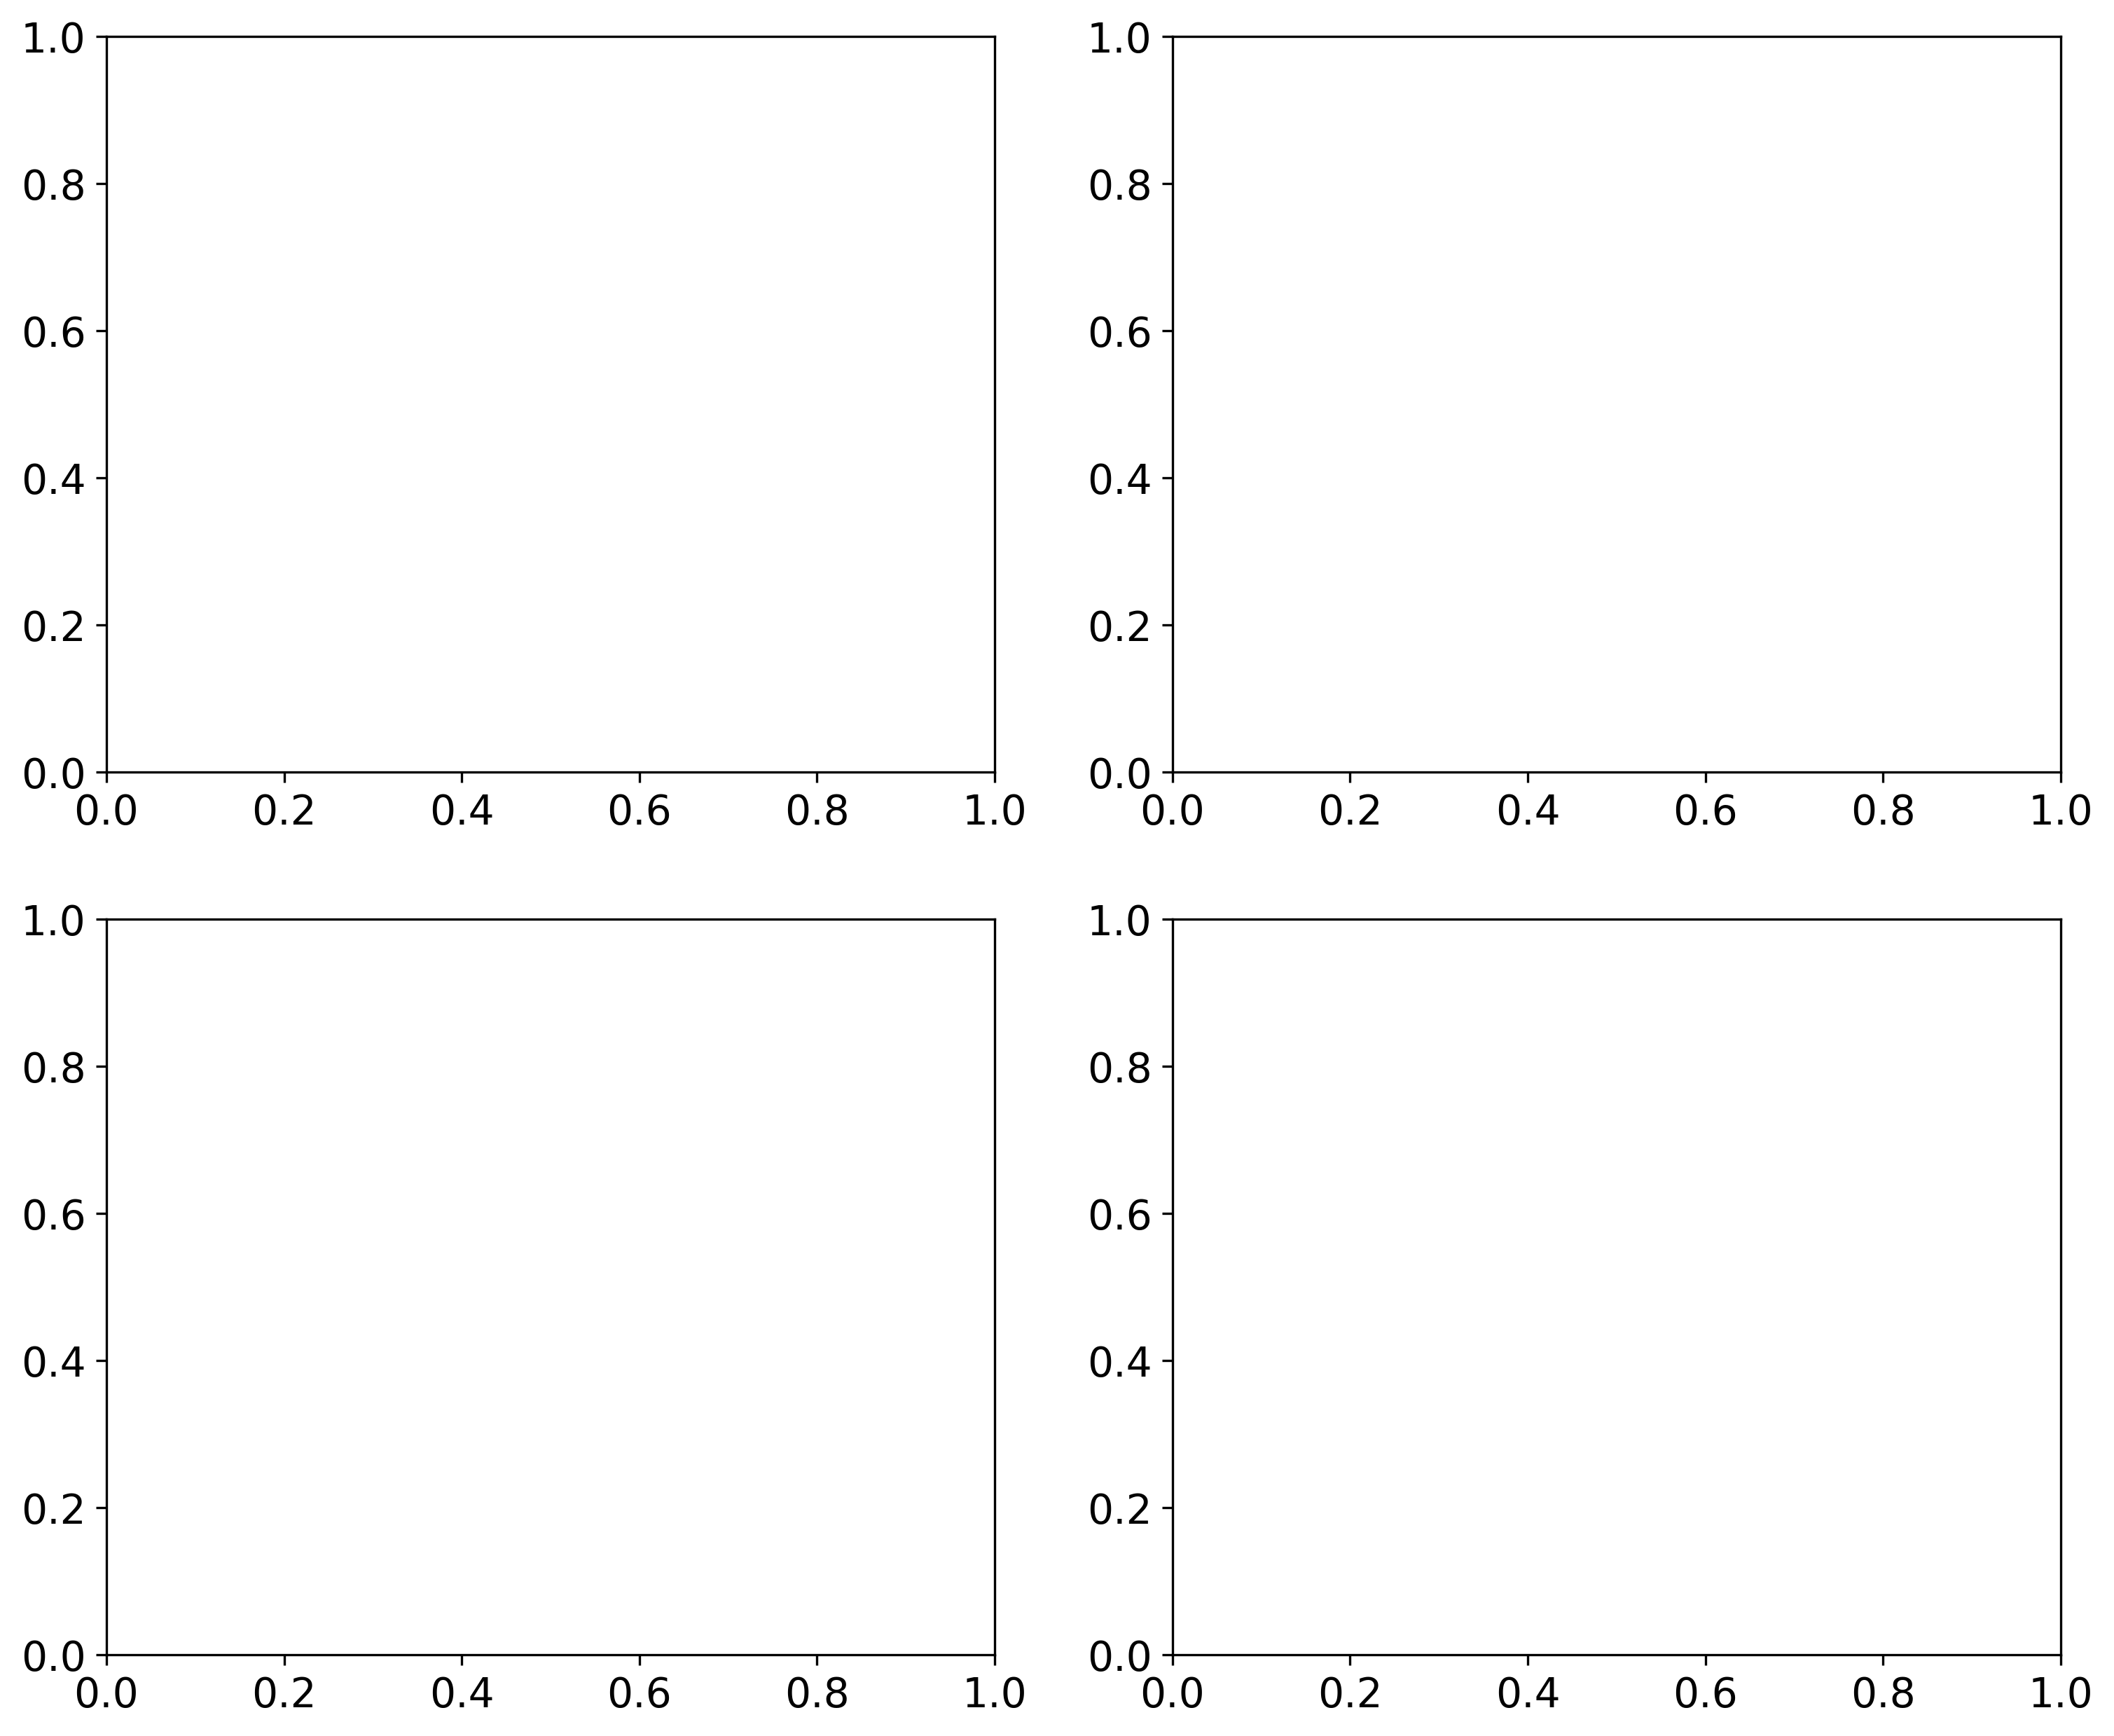

In [4]:
# STEP3.2_06_thesis_clustering_plots_v3.py
#
# 変更点: scoreがNaNの場合にエラーになる問題を修正 (dropnaを追加)
#

import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
from sklearn.metrics import adjusted_rand_score

# ==========================================
# 1. 設定 (Configuration)
# ==========================================

# ★ここをあなたの環境に合わせて書き換えてください★
RUN_ID = "20251130_153500"  # Rで計算したID
ROOT_BASE = "/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/20251026_under_25clusters_program_and_result/for_checking_20251127"

# 入力元
CLUSTERING_SUB_DIR = os.path.join(ROOT_BASE, "sub", "03_clustering_STEP3.2_signlessCorr", f"run_{RUN_ID}")

# 出力先
OUTPUT_FIG_DIR = os.path.join(ROOT_BASE, "Thesis_Figures", f"run_{RUN_ID}", "Clustering_Validation")
os.makedirs(OUTPUT_FIG_DIR, exist_ok=True)

# プロットスタイル
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Helvetica']
plt.rcParams['font.size'] = 14
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

# データセット定義
ALL_DATASETS = ["OH", "FP", "A_OH_plus_others", "B_FP_plus_others", "C_OH_only", "D_FP_only"]

# 主要な指標
MAIN_INDICES = ["silhouette", "gap", "dunn", "ch"]
INDEX_LABELS = {
    "silhouette": "(a) Silhouette (max)",
    "gap":        "(b) Gap Statistic (max)",
    "dunn":       "(c) Dunn Index (max)",
    "ch":         "(d) Calinski-Harabasz (max)"
}
INDEX_DIRECTIONS = {
    "silhouette": "max", "gap": "max", "dunn": "max", "ch": "max",
    "db": "min", "ptbiserial": "max"
}

print(f"Target Run ID: {RUN_ID}")
print(f"Output Directory: {OUTPUT_FIG_DIR}")

# ==========================================
# 2. ヘルパー関数
# ==========================================

def load_k_scores(dataset, unit, mode_dim="linear_top3", index="silhouette"):
    """R出力の k_score_*.csv を読み込む"""
    fname = f"k_score_{mode_dim}_{unit}_{dataset}_{index}_{RUN_ID}.csv"
    path = os.path.join(CLUSTERING_SUB_DIR, unit, dataset, "indices", fname)
    if not os.path.exists(path):
        return None
    return pd.read_csv(path)

def load_cluster_labels(dataset, unit, mode_dim="linear_top3", k_num=10):
    """R出力の固定kラベル (ClusterAssign_...kXX...) を読み込む"""
    fname = f"ClusterAssign_{mode_dim}_k{k_num}_{unit}_{dataset}_{RUN_ID}.csv"
    path = os.path.join(CLUSTERING_SUB_DIR, unit, dataset, "labels", fname)
    if not os.path.exists(path):
        return None
    df = pd.read_csv(path)
    if "Cluster" in df.columns:
        return df["Cluster"].values
    return None

# ==========================================
# 3. 図表作成: Main Text用 (指標グリッド図)
# ==========================================
print("\n--- Generating Main Text Figures (Clustering Indices) ---")

def plot_indices_grid(dataset):
    unit = "variables" if dataset in ["OH", "FP"] else "samples"
    target_mode = "linear_top3"

    fig = plt.figure(figsize=(12, 10))
    gs = GridSpec(2, 2, figure=fig)
    axes = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1]),
            fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])]
    
    colors = sns.color_palette("deep", len(MAIN_INDICES))
    plot_count = 0
    
    for i, (ax, index) in enumerate(zip(axes, MAIN_INDICES)):
        df = load_k_scores(dataset, unit, mode_dim=target_mode, index=index)
        
        # ★修正: データがない、または空の場合はスキップ
        if df is None or len(df) == 0: continue
        
        # ★修正: スコアがNaNの行を削除 (エラー回避)
        df = df.dropna(subset=["score"])
        if len(df) == 0: continue
        
        plot_count += 1
        ax.plot(df["k"], df["score"], marker='o', linestyle='-', linewidth=2, color=colors[i], alpha=0.8, label=target_mode)
        
        direction = INDEX_DIRECTIONS.get(index, "max")
        best_idx = df["score"].idxmax() if direction == "max" else df["score"].idxmin()
        best_k = df.loc[best_idx, "k"]
        best_score = df.loc[best_idx, "score"]
        
        # 赤丸強調
        ax.plot(best_k, best_score, marker='o', markersize=12, 
                markerfacecolor='none', markeredgecolor='red', markeredgewidth=2)
        ax.annotate(f"k={int(best_k)}", (best_k, best_score), 
                    xytext=(5, 5), textcoords='offset points', color='red', fontweight='bold')
        
        ax.set_title(INDEX_LABELS[index], fontweight="bold", loc='left')
        ax.set_xlabel("Number of clusters ($k$)")
        ax.set_ylabel("Score value")
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.set_xticks(np.arange(min(df["k"]), max(df["k"])+1, 2))
    
    if plot_count > 0:
        plt.suptitle(f"Clustering Validation Indices: {dataset} (Linear Top3)", y=0.98, fontsize=18, fontweight="bold")
        plt.tight_layout(rect=[0, 0.03, 1, 0.98])
        
        save_name = f"Main_Clustering_Indices_BestK_Grid_{dataset}"
        plt.savefig(os.path.join(OUTPUT_FIG_DIR, f"{save_name}.png"))
        plt.savefig(os.path.join(OUTPUT_FIG_DIR, f"{save_name}.pdf"))
        plt.close()
        print(f"  -> Generated Indices Grid for {dataset}")
    else:
        print(f"  -> [SKIP] No valid index data found for {dataset}")

for ds in ALL_DATASETS:
    plot_indices_grid(ds)


# ==========================================
# 4. 図表作成: Appendix用 (解像度間ARIヒートマップ)
# ==========================================
print("\n--- Generating Appendix Figures (Resolution ARI Heatmap) ---")

def plot_resolution_heatmap(dataset):
    unit = "variables" if dataset in ["OH", "FP"] else "samples"
    target_mode = "linear_top3"
    
    k_levels = [10, 25, 50]
    n_levels = len(k_levels)
    ari_matrix = np.zeros((n_levels, n_levels))
    
    labels_map = {}
    for k in k_levels:
        labels_map[k] = load_cluster_labels(dataset, unit, target_mode, k)
        
    if any(l is None for l in labels_map.values()):
        print(f"  -> [SKIP] Missing fixed-k labels for {dataset}")
        return

    for i in range(n_levels):
        for j in range(n_levels):
            if i == j:
                ari_matrix[i, j] = 1.0
            else:
                lab_i = labels_map[k_levels[i]]
                lab_j = labels_map[k_levels[j]]
                # ラベル長一致確認
                if len(lab_i) == len(lab_j):
                    ari_matrix[i, j] = adjusted_rand_score(lab_i, lab_j)
                else:
                    ari_matrix[i, j] = np.nan

    fig, ax = plt.subplots(figsize=(7, 6))
    mask = np.triu(np.ones_like(ari_matrix, dtype=bool))
    
    sns.heatmap(ari_matrix, mask=mask, annot=True, fmt=".2f", cmap="YlGnBu", 
                vmin=0, vmax=1, cbar_kws={'label': 'Adjusted Rand Index (ARI)'},
                xticklabels=[f"k={k}" for k in k_levels],
                yticklabels=[f"k={k}" for k in k_levels],
                ax=ax, annot_kws={"size": 14, "weight": "bold"})
    
    ax.set_title(f"Resolution Consistency (ARI): {dataset}\n(Linear Top3)", fontweight="bold")
    plt.yticks(rotation=0) 
    plt.tight_layout()
    
    save_name = f"Appendix_ARI_Resolution_Heatmap_{dataset}"
    plt.savefig(os.path.join(OUTPUT_FIG_DIR, f"{save_name}.png"))
    plt.savefig(os.path.join(OUTPUT_FIG_DIR, f"{save_name}.pdf"))
    plt.close()
    print(f"  -> Generated ARI Heatmap for {dataset}")

for ds in ALL_DATASETS:
    plot_resolution_heatmap(ds)

print("\n✅ All Clustering Figures Generated Successfully!")
print(f"Check the folder: {OUTPUT_FIG_DIR}")